# Analisi del leakage — paper Yan et al. (2024)

Questo notebook documenta e verifica i tre problemi metodologici nel setup originale che producono un R² ≈ 0.99 "finto", prima di passare alla pipeline corretta (Giorno 2 del piano).

**I tre problemi:**
1. Il target è quasi una funzione deterministica di un input (formula ET0 × Kc − pioggia)
2. Il modello vede gli input del giorno *t* per predire il target dello stesso giorno *t* — nessun vero orizzonte di previsione
3. La normalizzazione (min/max) è calcolata su tutto il dataset, incluso il test set — leakage statistico


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carica il dataset originale
df = pd.read_excel("data/data-ready-def.xlsx")
df.head()

3519

## Problema 1 — il target è (quasi) una funzione deterministica degli input

La colonna target `Amount of irrigation` non è una grandezza misurata in modo indipendente: nel paper originale viene calcolata con la formula ET0 × Kc − pioggia, dove ET0 (evapotraspirazione di riferimento) è essa stessa una delle feature che il modello riceve in input.

In altre parole: il modello non sta "imparando a prevedere l'irrigazione" — sta imparando a invertire una formula nota, di cui possiede già uno degli ingredienti principali. Per questo basta una rete qualsiasi per arrivare a R² altissimo: non c'è vera incertezza da risolvere, è quasi un problema di algebra travestito da forecasting.


Correlazione ET0 vs Amount of irrigation: 0.3722


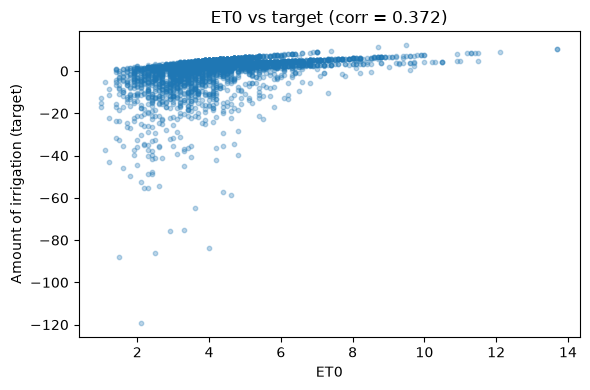


Correlazione di ogni feature col target:
Hours of sunshine(h)               0.530639
ET0                                0.372220
Air pressure on the ground(hPa)    0.213332
Maximum temperature(¡æ)            0.200422
Water demand                       0.198632
Average temperatures(¡æ)           0.103486
Minimum temperature(¡æ)           -0.026082
Date                              -0.052003
Wind velocity(m/s)                -0.076295
Relative humidity(%)              -0.406730
Precipitation(mm)                 -0.983508
dtype: float64


In [2]:
# Verifica empirica: la correlazione tra ET0 e il target dovrebbe essere altissima
corr = df['ET0'].corr(df['Amount of irrigation'])
print(f"Correlazione ET0 vs Amount of irrigation: {corr:.4f}")

plt.figure(figsize=(6, 4))
plt.scatter(df['ET0'], df['Amount of irrigation'], alpha=0.3, s=10)
plt.xlabel('ET0')
plt.ylabel('Amount of irrigation (target)')
plt.title(f'ET0 vs target (corr = {corr:.3f})')
plt.tight_layout()
plt.savefig('results/trick_correlation.png', dpi=150)
plt.show()

# Bonus: correlazione di TUTTE le feature col target, per vedere se altre colonne sono altrettanto "sospette"
feature_cols = [c for c in df.columns if c != 'Amount of irrigation']
corr_with_target = df[feature_cols].corrwith(df['Amount of irrigation']).sort_values(ascending=False)
print("\nCorrelazione di ogni feature col target:")
print(corr_with_target)


## Problema 2 — nessun vero orizzonte di previsione (same-day prediction)

Nel codice originale, `create_dataset` costruisce le sequenze così: la finestra di input copre i giorni [i-20, ..., i-1] e il target predetto è `dataset[i-1, col]` — cioè il valore dell'**ultimo giorno della finestra di input stessa**, non un giorno futuro.

È come fare un esame mostrando allo studente le risposte e chiedendogli di "prevedere" le stesse risposte: il modello fa reconstruction, non forecasting. Per questo nel Giorno 2 introduciamo il parametro H (horizon) e prediciamo `dataset[i-1+H, col]` con H ≥ 1, così il target è davvero nel futuro rispetto all'ultimo giorno osservato.

Non c'è una metrica da calcolare qui — è un problema di indicizzazione nel codice, verificabile leggendo `create_dataset` riga per riga in `Main2_cnn_bilstm_attention.py`.


## Problema 3 — normalizzazione calcolata sull'intero dataset (leakage statistico)

Il codice originale calcola min e max per la normalizzazione con `NormalizeMult(data)` su **tutto** il dataframe, prima di dividerlo in train/val/test. Questo significa che le statistiche di scaling "vedono" già i valori del test set — un leakage di informazione dal futuro verso il passato.

È un errore sottile: il modello non vede direttamente i valori del test set, ma i range di normalizzazione sono influenzati da essi, il che rende il task leggermente più facile di quanto sarebbe in un deployment reale, dove i dati futuri ovviamente non sono disponibili al momento del training.

Anche questo verrà corretto nel Giorno 2, calcolando min/max solo sulle righe di training (2000–2016).


## Conclusione

Questi tre problemi — combinati — spiegano l'R² ≈ 0.99 ottenuto nel setup originale:
- il target è quasi una funzione nota di un input (leakage strutturale via la formula)
- non c'è vero orizzonte temporale (leakage temporale, same-day)
- la normalizzazione "vede" il futuro (leakage statistico)

Questo risultato (`results/trick_result.png`) è il "prima" che confronterai col "dopo" (pipeline corretta, Giorno 2) nel capitolo dei risultati della tesi — il salto da R² ≈ 0.99 a R² ≈ 0.06 sarà il risultato più forte e onesto della tesi (RQ4, Cap. 4.1).


### PROVA DEL 9 ###

Proviamo ad applicare un modello di regressione lineare semplice sulle 8 feature, e vediamo che R^2 ci mostra. 

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df[feature_cols].values
y = df['Amount of irrigation'].values

lr = LinearRegression().fit(X, y)
y_pred = lr.predict(X)
r2_linear = r2_score(y, y_pred)
print(f"R^2 di una regressione lineare (stesso giorno, 8 feature) sul target: {r2_linear:.4f}")

# Se questo R^2 e' alto (es. > 0.7-0.8) nonostante la correlazione univariata con ET0 sia moderata,
# e' la prova che il target e' quasi una funzione (lineare o quasi) delle feature dello stesso giorno --
# coerente con l'ipotesi della formula ET0 x Kc - pioggia, solo che Kc agisce come un peso che varia
# nel tempo e che la sola correlazione con ET0 non riesce a catturare da sola.


R^2 di una regressione lineare (stesso giorno, 8 feature) sul target: 0.9905


### Perché la correlazione con ET0 da sola può essere solo moderata

Il target è ET0 × Kc − pioggia, non ET0 da solo. Kc (coefficiente di crescita della coltura) varia durante la stagione (basso nelle fasi iniziali, alto al picco vegetativo), quindi lo stesso valore di ET0 può corrispondere a target molto diversi secondo il momento della stagione e quanto ha piovuto. Una correlazione lineare univariata si "diluisce" per questo motivo — non significa che il leakage non ci sia.

Il test più corretto è multivariato: se una regressione lineare semplice sulle 8 feature dello stesso giorno spiega già gran parte della varianza del target, è la prova che il target è quasi-deterministico dato l'input dello stesso giorno — molto più convincente della singola correlazione con ET0.
